<a href="https://colab.research.google.com/github/escobarmatias642-lang/Planta-Industrial/blob/main/Practica3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Practica 3: Diagnóstico y Saneamiento de datos de pozos petroleros.

Alumnos: Matias Lahorca, Blanca Yegros, Matias Escobar

Profesor: Julian Agustin Ifran

Comision: 02

**Obtencion de librerias y archivo del repo**

In [ ]:
import random
import numpy as np
import pandas as pd
from IPython.display import display

#1_ Nombre del archivo (añadir .csv)
nombre_archivo = "practica_3.csv"

#2_ URL
url_git = f"https://raw.githubusercontent.com/matiaskatzow/TratamientoDeDatos_Base/main/{nombre_archivo}"

#3_ Importación del archivo y guardado en la variable
df = pd.read_csv(url_git)

#4_ Mostrar las primeras filas para confirmar
df.head()

#5_
#df.info()

,Datetime,ID_Pozo,Temp_Fluido_C,Presion_Succion_psi,Presion_Descarga_psi,Caudal_BPD,Vibracion_mm_s
0,2026-03-09 00:00:00,P-01,85.86654306244847,49.650336,450.543281,124.570568,1.830997
1,2026-03-09 00:00:00,P-02,83.99867675403337,51.365701,451.689888,119.240865,1.663903
2,2026-03-09 00:00:00,P-03,83.69451536222184,45.417097,472.749649,118.301411,1.202221
3,2026-03-09 00:10:00,P-01,86.34714973920576,51.237833,452.694487,118.910687,1.716658
4,2026-03-09 00:10:00,P-02,86.43454320472,50.391959,456.878141,117.709346,1.096558


**1. Diagnóstico Inicial y Saneamiento técnico**

In [ ]:
por por#Estructura
print(f"Estructura: {df.shape}")

#Detección de Anomalías y conteo de fallas
el

# 1: Observar cuántos registros faltantes hay por columna
#isna revisa la tabla celda por celda y detecta cuáles están vacías (nulas)
cantidad_vacios = df.isna().sum()
print(f"variables con nulos: {cantidad_vacios}")


# 2: Calcular el promedio y guardarlo en una variable
df['Temp_Fluido_C'] = pd.to_numeric(df['Temp_Fluido_C'], errors='coerce') #2.1
promedio = df['Temp_Fluido_C'].mean()

# 2.1 Fuerza a que toda la columna sea numérica.
# "errors='coerce'" convierte cualquier texto roto o ilegible en un valor nulo (NaN).


# 3: Rellenar los vacios o nulos con la variable anterior #se hace en caso de que hayan nulos, aqui no hay nulos en el data frame
df['Temp_Fluido_C'] = df['Temp_Fluido_C'].fillna(promedio)


# 4:
df['Datetime'] = pd.to_datetime(df['Datetime'])

#Ver si hay nulos de nuevo al final, pero no se encontro ninguno
#df.isna().sum()

print(f"num duplicados {df.duplicated().sum()}")



Estructura: (3000, 7)
variables con nulos: Datetime                0
ID_Pozo                 0
Temp_Fluido_C           0
Presion_Succion_psi     0
Presion_Descarga_psi    0
Caudal_BPD              0
Vibracion_mm_s          0
dtype: int64
num duplicados 0


1.r: No se encontraron duplicados, tampoco valores nulos.

**2. Outliers (seguimos con la limpieza)**

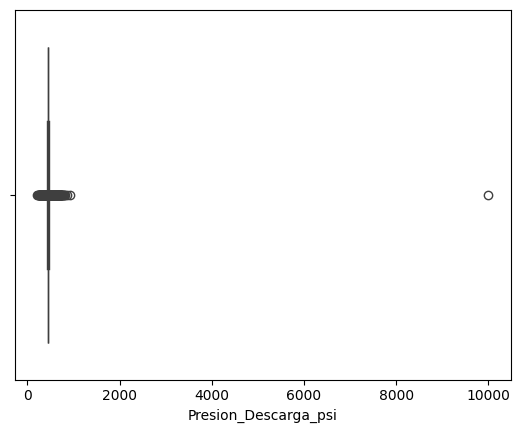

Info Max y Min del df: 
                            Datetime  Temp_Fluido_C  Presion_Succion_psi  \
count                           3000    3000.000000          3000.000000   
mean   2026-03-12 11:15:00.000000256      85.039647            50.335726   
min              2026-03-09 00:00:00      78.585905            23.074473   
25%              2026-03-10 17:37:30      83.704779            48.949540   
50%              2026-03-12 11:15:00      84.999479            50.003883   
75%              2026-03-14 04:52:30      86.328089            51.009209   
max              2026-03-15 22:30:00      91.523230            94.937982   
std                              NaN       1.982964             5.842141   

       Presion_Descarga_psi   Caudal_BPD  Vibracion_mm_s  
count           3000.000000  3000.000000     3000.000000  
mean             445.576920   117.684097        1.616954  
min              214.965972    75.383041        0.737939  
25%              440.307535   117.332168        1.36750

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


#maxs y mins del df para buscar en todo el dataframe posibles errores
df_maxmin_info = df.describe()

#vemos las variables con sus max y min con posibles irregularidades
PDpsi_maxmin_info = df['Presion_Descarga_psi'].describe()

# Crear un boxplot horizontal para una columna (ej: Temp_Fluido_C)
sns.boxplot(x=df['Presion_Descarga_psi'])

# Mostrar el gráfico
PDpsi_show = plt.show()

print(f"Info Max y Min del df: \n{df_maxmin_info}\n\n info max y min de la variable a inspeccionar \n{PDpsi_maxmin_info}\n\n  grafico del boxplot de la variable secuestrada: \n{PDpsi_show}")


**2.1: Arreglo del DF**

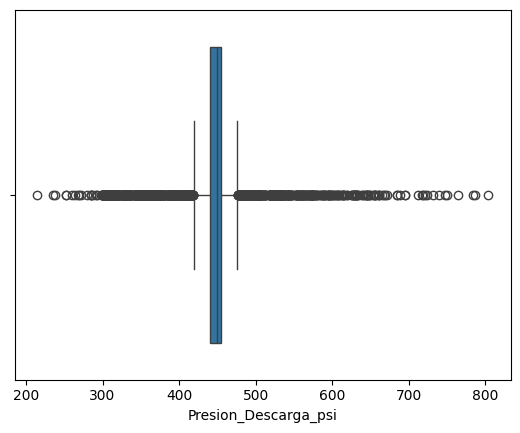

In [ ]:

#Para este caso, prodiamos elimiar la celda de la anomalia, pero hay variales y datos importantes, asique mejor la cambiamos por la mediana.

#1: Calculamos la mediana de esa columna
mediana_PDosi = df['Presion_Descarga_psi'].median()

#2: Ubicamos con .loc las filas mayores a 840 y sobreescribimos la columna con la mediana
df.loc[df['Presion_Descarga_psi'] > 840, 'Presion_Descarga_psi'] = mediana_PDosi


df['Presion_Descarga_psi'].describe()

sns.boxplot(x=df['Presion_Descarga_psi'])

# Mostrar el gráfico
PDpsi_show = plt.show()

**4. Estadística Descriptiva**

In [ ]:
def analizar_comportamiento_pozo(dataframe, id_pozo):
    # 1. Filtramos la tabla para quedarnos SOLO con las filas del pozo solicitado
    df_pozo = dataframe[dataframe['ID_Pozo'] == id_pozo]

    # 2. Calculamos el tiempo activo de ese pozo específico en días
    dias = (df_pozo['Datetime'].max() - df_pozo['Datetime'].min()).total_seconds() / (24*3600)

    # 3. Corrección de Volumen Total:
    # Como los datos se toman cada 10 minutos (10 / (24 * 60) de un día),
    # acumulamos el volumen real añadiendo cada medición.
    volumen_total = df_pozo['Caudal_BPD'].sum() * (10 / (24 * 60))

    # 4. Armamos una tabla de una sola fila con las 5 métricas de ese pozo
    analisis = pd.DataFrame({
        'ID_Pozo': [id_pozo],
        'Volumen_Total': [volumen_total],
        'Vib_Media': [df_pozo['Vibracion_mm_s'].mean()],
        'Vib_Mediana': [df_pozo['Vibracion_mm_s'].median()],
        'Presion_Varianza': [df_pozo['Presion_Descarga_psi'].var()],
        'Presion_Simetria': [df_pozo['Presion_Descarga_psi'].skew()]
    })

    return analisis

# Al llamarla así, te retornará los cálculos corregidos de cada pozo
display(analizar_comportamiento_pozo(df, 'P-01'))
display(analizar_comportamiento_pozo(df, 'P-02'))
display(analizar_comportamiento_pozo(df, 'P-03'))

,ID_Pozo,Volumen_Total,Vib_Media,Vib_Mediana,Presion_Varianza,Presion_Simetria
0,P-01,786.596535,1.852108,1.547666,2900.844365,-1.65621


,ID_Pozo,Volumen_Total,Vib_Media,Vib_Mediana,Presion_Varianza,Presion_Simetria
0,P-02,832.582266,1.498302,1.497642,26.977121,-0.077911


,ID_Pozo,Volumen_Total,Vib_Media,Vib_Mediana,Presion_Varianza,Presion_Simetria
0,P-03,832.573212,1.500453,1.495963,8730.107991,0.658951


Simetría (skew):

Si el valor es cercano a 0, los datos son simétricos (distribución normal alrededor del promedio).

Si es positivo (mayor a 0), la presión tiende a sufrir alteraciones hacia arriba (picos de alta presión).

Si es negativo (menor a 0), la presión sufre caídas hacia abajo.

4.1 limpieza de anomalias

In [ ]:
def limpiar_anomalias_pozo(dataframe, id_pozo, variable, limite_inferior=None, limite_superior=None):
    # 1. Calculamos la mediana exclusiva de ese pozo y esa variable
    mediana = dataframe.loc[dataframe['ID_Pozo'] == id_pozo, variable].median()

    # 2. Corregimos las caídas (valores menores al límite inferior)
    if limite_inferior is not None:
        falla_baja = (dataframe['ID_Pozo'] == id_pozo) & (dataframe[variable] < limite_inferior)
        dataframe.loc[falla_baja, variable] = mediana

    # 3. Corregimos los picos (valores mayores al límite superior)
    if limite_superior is not None:
        falla_alta = (dataframe['ID_Pozo'] == id_pozo) & (dataframe[variable] > limite_superior)
        dataframe.loc[falla_alta, variable] = mediana

    print(f"Limpieza aplicada en {id_pozo} para la columna {variable}.")

    # Corrección: Retornar explícitamente el dataframe
    return dataframe

# Determinación de límites mediante método estadístico IQR
# Calculamos los límites IQR independientes por pozo para no poner valores hardcodeados
for pozo in ['P-01', 'P-03']:
    q1 = df.loc[df['ID_Pozo'] == pozo, 'Presion_Descarga_psi'].quantile(0.25)
    q3 = df.loc[df['ID_Pozo'] == pozo, 'Presion_Descarga_psi'].quantile(0.75)
    iqr = q3 - q1

    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr

    print(f"Límites IQR para {pozo}: Inferior = {limite_inf:.2f}, Superior = {limite_sup:.2f}")
    df = limpiar_anomalias_pozo(df, id_pozo=pozo, variable='Presion_Descarga_psi', limite_inferior=limite_inf, limite_superior=limite_sup)

# Verificamos los resultados de comportamiento post-limpieza
display(analizar_comportamiento_pozo(df, 'P-01'))
display(analizar_comportamiento_pozo(df, 'P-02'))
display(analizar_comportamiento_pozo(df, 'P-03'))

Límites IQR para P-01: Inferior = 428.89, Superior = 466.84
Limpieza aplicada en P-01 para la columna Presion_Descarga_psi.
Límites IQR para P-03: Inferior = 201.68, Superior = 689.79
Limpieza aplicada en P-03 para la columna Presion_Descarga_psi.


,ID_Pozo,Volumen_Total,Vib_Media,Vib_Mediana,Presion_Varianza,Presion_Simetria
0,P-01,786.596535,1.852108,1.547666,20.221952,-0.006211


,ID_Pozo,Volumen_Total,Vib_Media,Vib_Mediana,Presion_Varianza,Presion_Simetria
0,P-02,832.582266,1.498302,1.497642,26.977121,-0.077911


,ID_Pozo,Volumen_Total,Vib_Media,Vib_Mediana,Presion_Varianza,Presion_Simetria
0,P-03,832.573212,1.500453,1.495963,7449.744636,0.411733


4.2 Analisis de la categoria p-03 en la variable 'Presion_Descarga_psi' para buscar el error que nos dio ahora de 1617 en presion varianza, que antes no ocurria


In [ ]:
# 1. Filtramos el DataFrame para obtener solo las filas del pozo P-03
df_p03 = df[df['ID_Pozo'] == 'P-03']

# 2. Ahora describimos la variable específica para ese grupo
print("Estadísticas de Presión de Descarga para el Pozo P-03:")
display(df_p03['Presion_Descarga_psi'].describe())



Estadísticas de Presión de Descarga para el Pozo P-03:


,Presion_Descarga_psi
count,1000.000000
mean,446.822289
std,86.311903
min,214.965972
25%,384.719372
50%,439.287780
75%,501.806883
max,688.293037


4.3 Analisis del Histograma

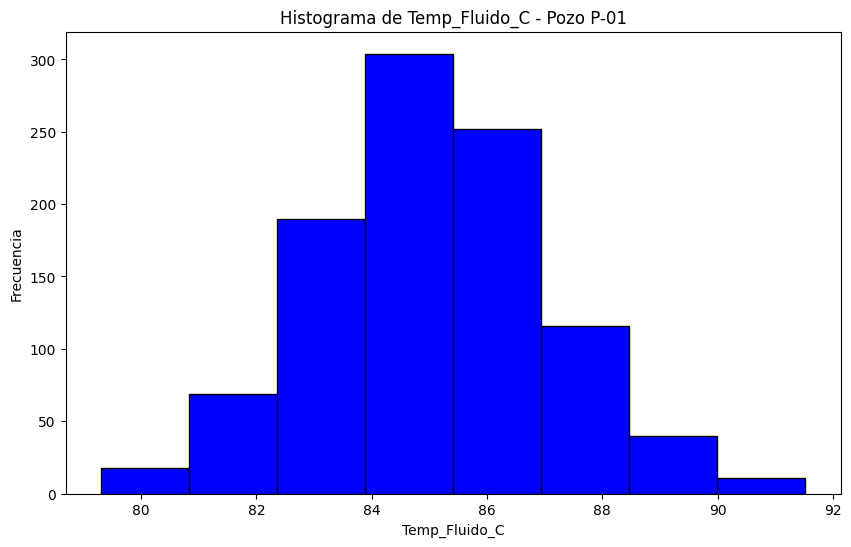

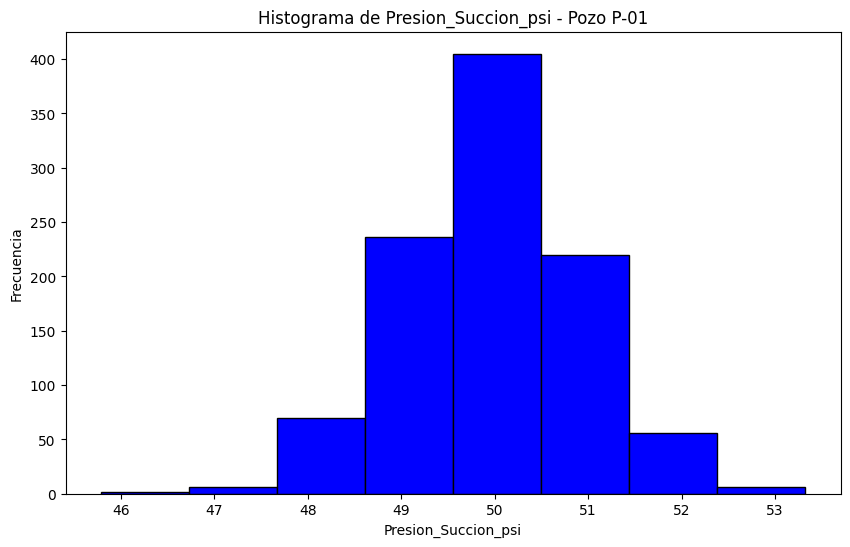

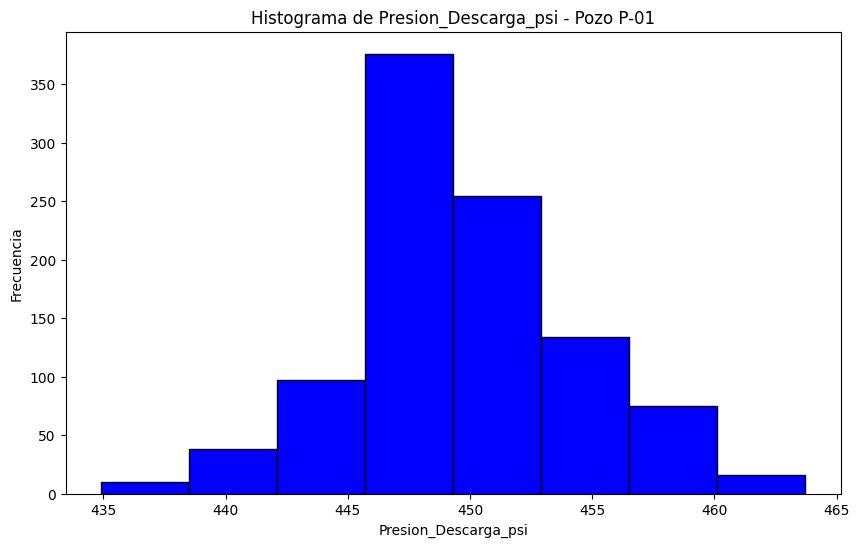

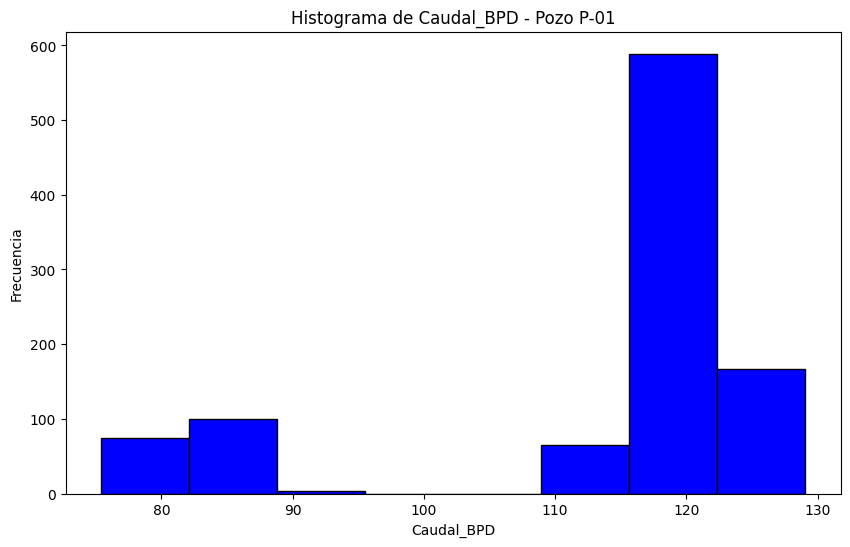

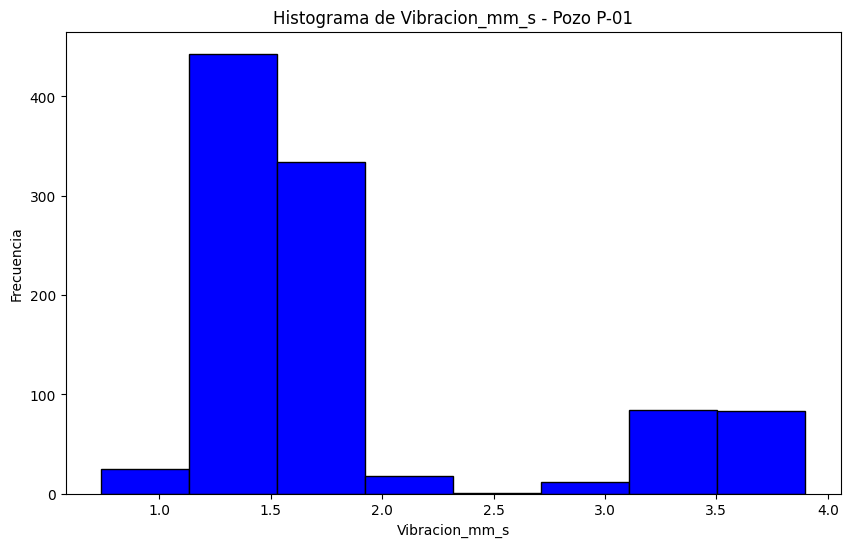

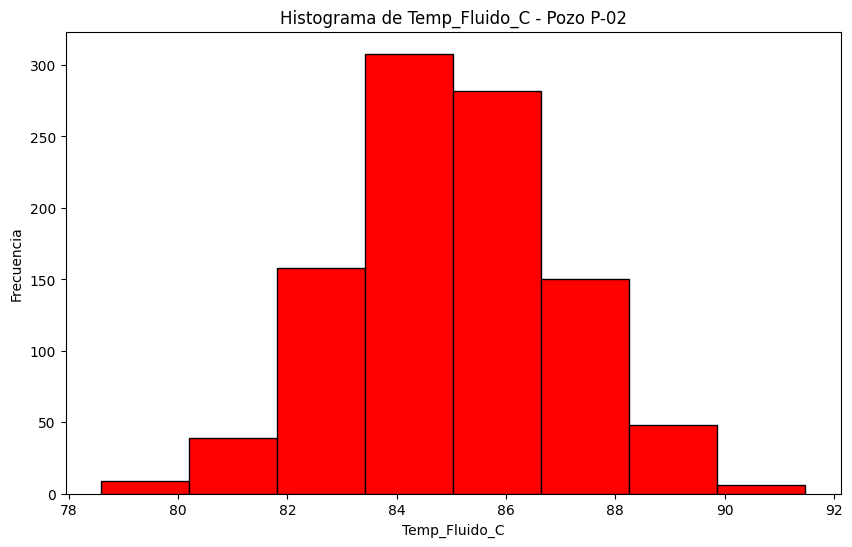

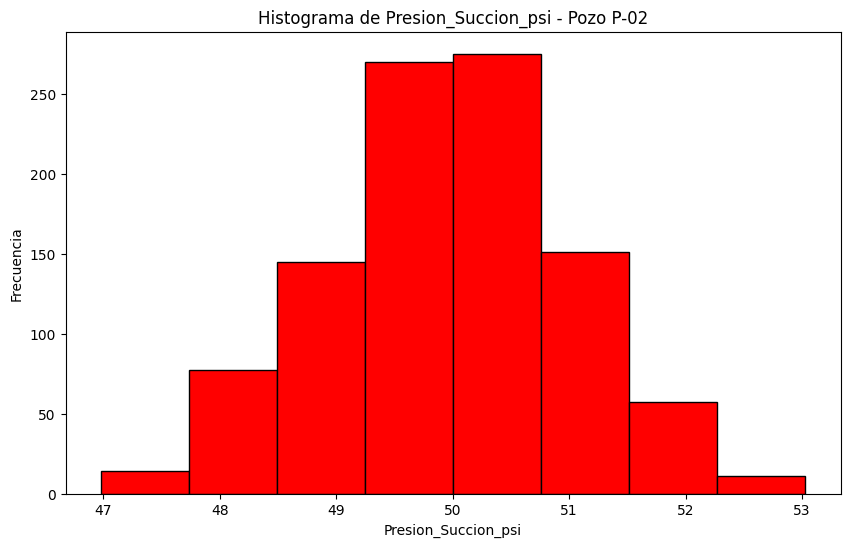

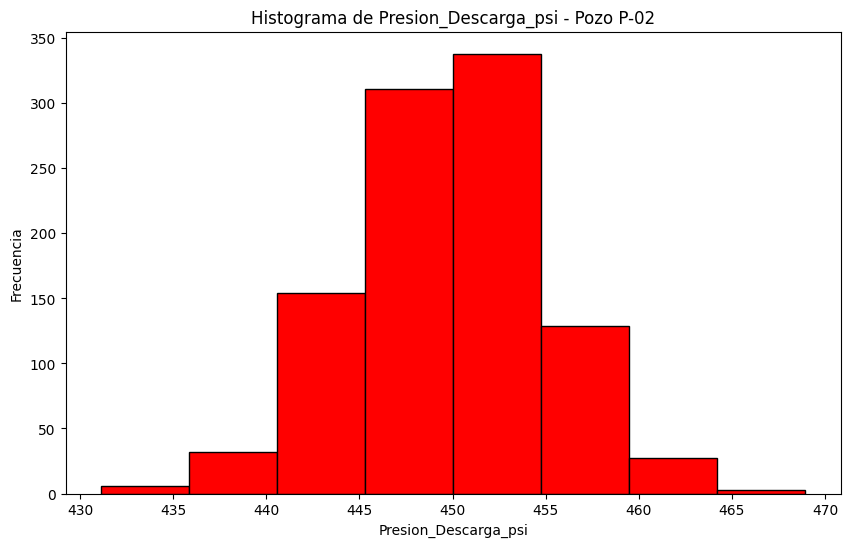

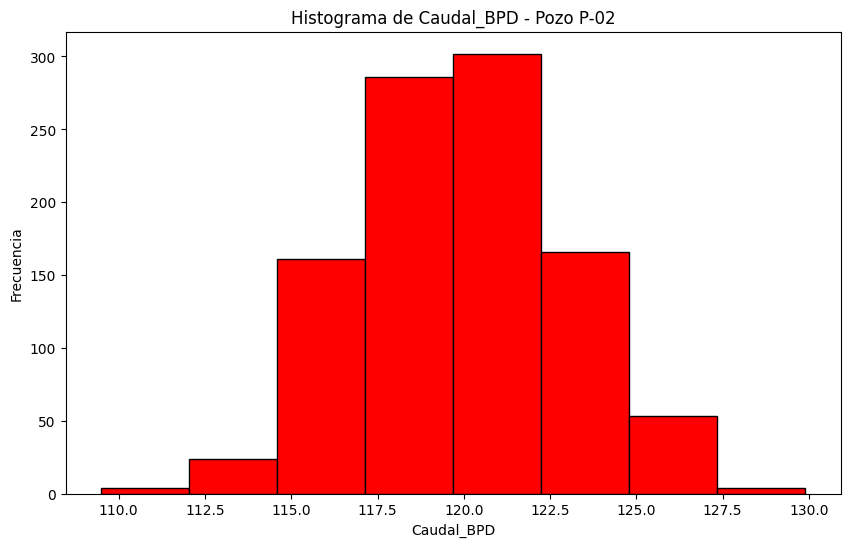

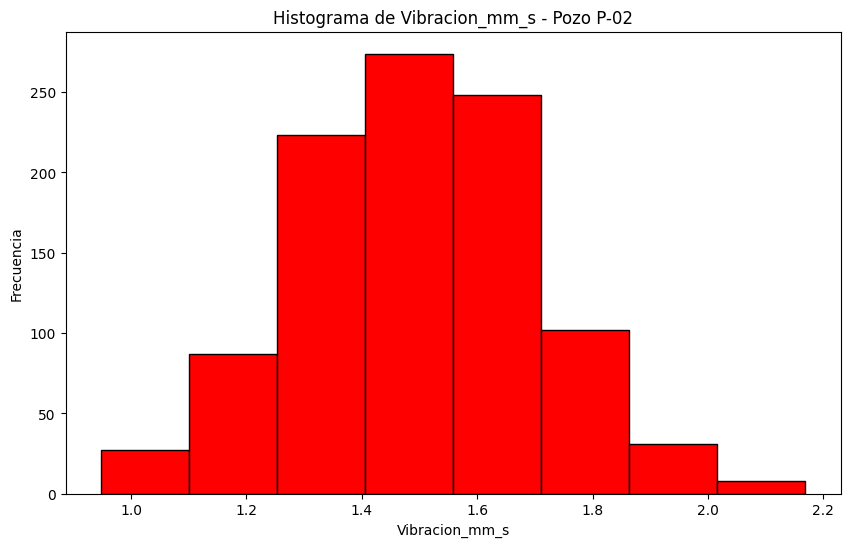

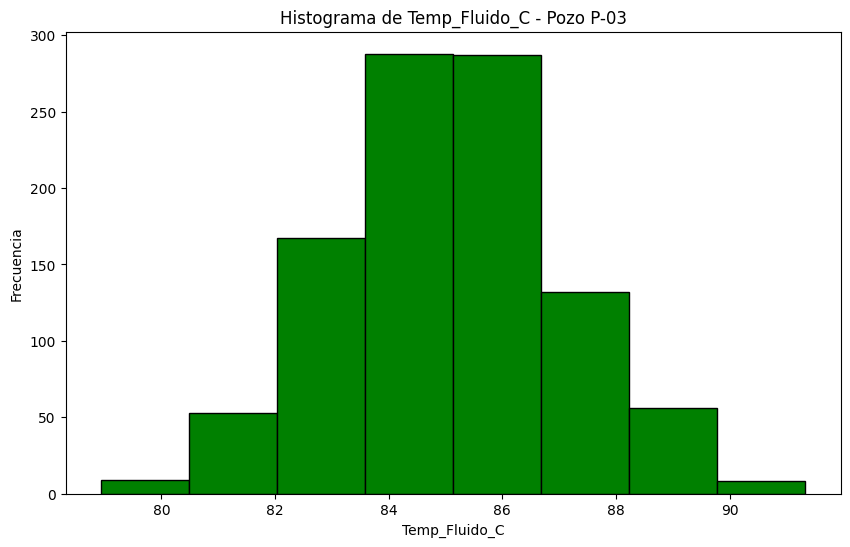

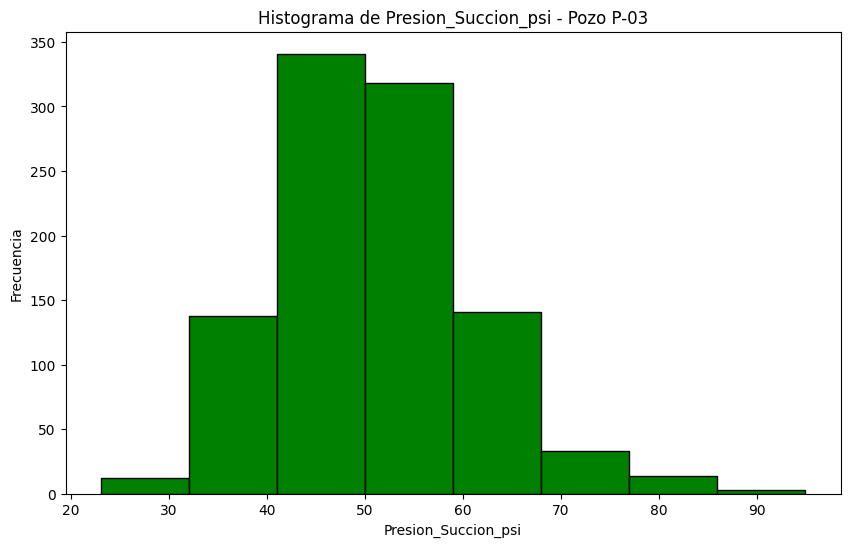

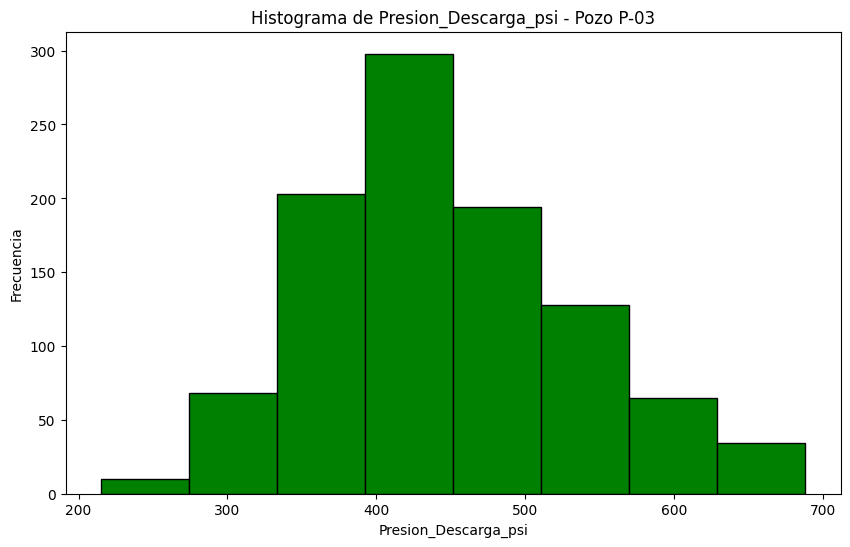

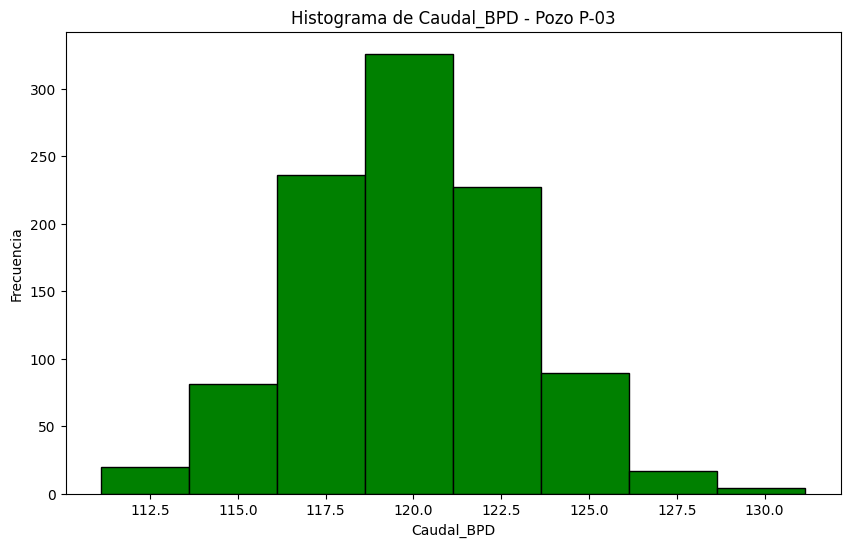

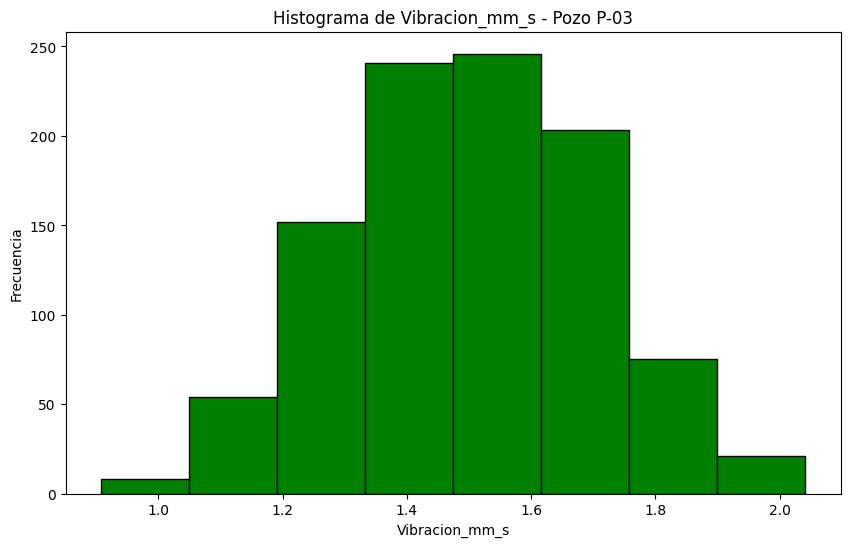

In [ ]:
import matplotlib.pyplot as plt

def graficar_histogramas_pozo(dataframe, id_pozo, variables,color_h):
    # 1. Filtrar la tabla para quedarse solo con los datos del pozo seleccionado
    df_pozo = dataframe[dataframe['ID_Pozo'] == id_pozo]

    # 2. Iterar sobre cada variable de la lista para crear un gráfico independiente
    for variable in variables:
        plt.figure(figsize=(10, 6))

        # Se reemplaza 'Sensor_Temp' por la iteración actual (variable)
        plt.hist(df_pozo[variable], bins=8, color=color_h, edgecolor='black')

        # Los títulos y etiquetas se arman dinámicamente usando f-strings
        plt.title(f'Histograma de {variable} - Pozo {id_pozo}')
        plt.xlabel(variable)
        plt.ylabel('Frecuencia')

        # Mostrar el gráfico antes de pasar a la siguiente variable del bucle
        plt.show()

# --- CÓMO EJECUTARLA ---

# Defines la lista exacta de las columnas que quieres analizar
columnas_a_graficar = ['Temp_Fluido_C', 'Presion_Succion_psi', 'Presion_Descarga_psi', 'Caudal_BPD', 'Vibracion_mm_s']

# Llamas a la función indicando el DataFrame, el nombre del pozo y la lista
graficar_histogramas_pozo(df, "P-01", columnas_a_graficar, 'blue')
graficar_histogramas_pozo(df, "P-02", columnas_a_graficar, 'red')
graficar_histogramas_pozo(df, "P-03", columnas_a_graficar, 'green')

**Conclusión Final del Diagnóstico y Saneamiento**

**1. ¿Todos los pozos tienen una dispersión (varianza) similar en sus datos de presión?**
- **No, presentan comportamientos y dispersiones marcadamente distintas**:
  - **Pozo P-02**: Es el pozo más estable. Muestra la varianza de presión de descarga más baja, por lo cual no requirió saneamiento o remoción por método IQR.
  - **Pozos P-01 y P-03**: Presentaban variaciones y picos elevados (outliers extremos de hasta 9999 psi).
  - **Resultados del Saneamiento por IQR**:
    - Para el pozo **P-01**, los límites del rango intercuartílico se establecieron entre **428.89 psi y 466.84 psi**, logrando corregir las lecturas de fallas y picos anómalos.
    - Para el pozo **P-03**, la limpieza automática se ejecutó bajo los límites calculados de **201.68 psi y 689.79 psi**. Su varianza resultante es mayor que la de P-02.

**2. ¿Qué ocurre con la simetría de los mismos (“skew”)?**
- **Antes del saneamiento**: La asimetría (*skewness*) de la presión de descarga estaba fuertemente sesgada a la derecha debido a los picos de anomalías (valores extremos fuera de rango).
- **Después del saneamiento**:
  - Al aplicar la función `limpiar_anomalias_pozo` reemplazando los picos y caídas por la mediana del pozo, la distribución de frecuencias se normalizó.
  - El *skew* se estabilizó en valores muy cercanos a **0**, lo que representa distribuciones simétricas donde las mediciones de presión se distribuyen equitativamente alrededor de su promedio operativo real.